## Bar Chart


In [1]:
# imports
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os
import vegafusion as vf

In [2]:
# getting variables to query database
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [3]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""


In [4]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )

In [5]:
# aggregate the data 
df_purchase_agg = df_purchase.group_by("user_id").agg(frequency=pl.col("user_session").n_unique(), monetary_value=pl.col("price").sum())

/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


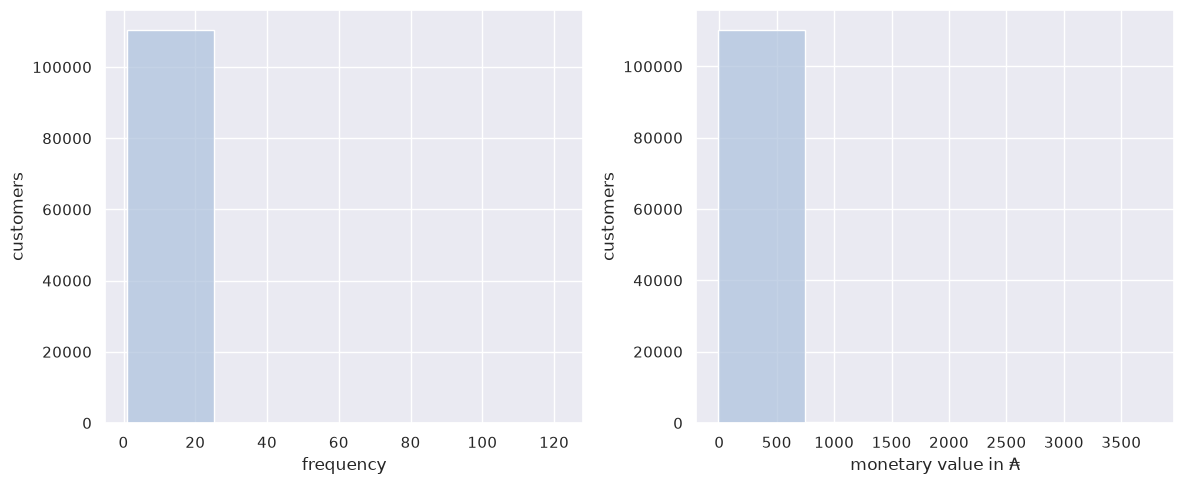

In [7]:
## 2. Plot using Seaborn
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Frequency
sns.histplot(
    data=df_purchase_agg,
    x="frequency",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_xlabel("frequency")
axes[0].set_ylabel("customers")

# Right Plot: Monetary Value
sns.histplot(
    data=df_purchase_agg,
    x="monetary_value",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_xlabel("monetary value in ₳")
axes[1].set_ylabel("customers")

plt.tight_layout()
plt.show()

/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


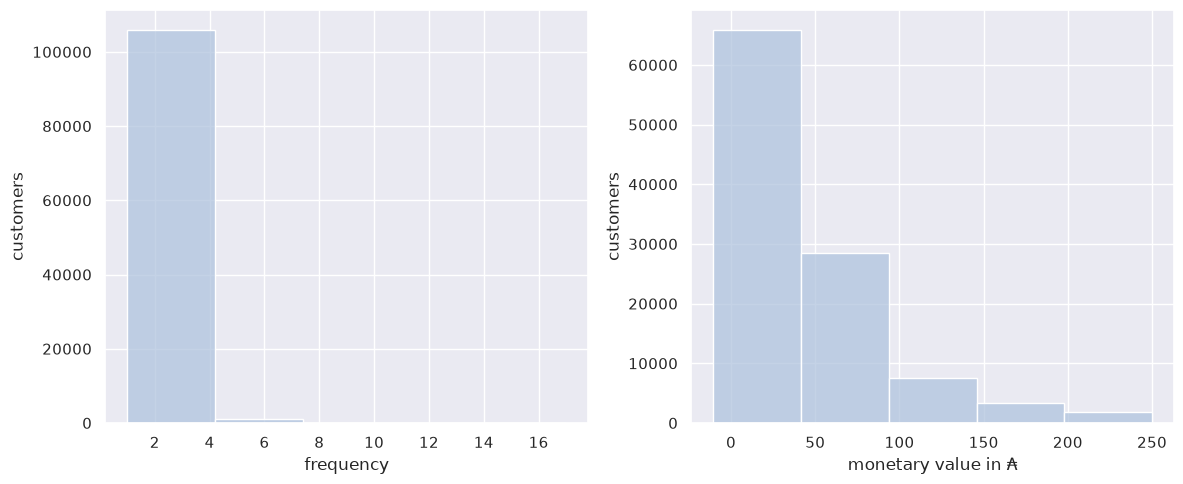

In [8]:
# 1. Filter out extreme outliers for cleaner visualization
plot_df = df_purchase_agg.filter(
    (pl.col("frequency") <= 40) & 
    (pl.col("monetary_value") <= 250)
)

# 2. Plot using histplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=plot_df,
    x="frequency",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_xlabel("frequency")
axes[0].set_ylabel("customers")

sns.histplot(
    data=plot_df,
    x="monetary_value",
    bins=5,
    color="lightsteelblue",
    edgecolor="white",
    ax=axes[1]
)
axes[1].set_xlabel("monetary value in ₳")
axes[1].set_ylabel("customers")

plt.tight_layout()
plt.show()

## Dollars spent by customers